# Outgoing Connection Pruning: Snowball Effect

## Motivation

We want to understand whether greedy per-connection pruning naturally drives hidden units toward single-task specialization. The hypothesis:

1. A unit connected to outputs of multiple tasks will have lower per-connection utility for the task it's less informative about
2. Pruning one output connection to task A reduces gradient signal from task A, causing the unit to specialize away from A
3. This **snowballs** — each prune from task A makes the next prune more likely to also be from task A, until the unit is fully specialized

## Setup

- **Two independent regression tasks**: `y1 = A1 @ x1`, `y2 = A2 @ x2` (each R³→R³, A matrices are ±1)
- **3 hidden units**, ReLU, fully connected to all 6 inputs and 6 outputs (36 total connections)
- **SGD** training, one sample at a time
- **Per-connection utility** (EMA, decay=0.999): `|activation| × |weight|`
- **Pruning**: train until utilities stabilize → prune lowest-utility connection → repeat until all 36 are gone

Two utility modes tested:
- **Contribution**: each layer's utilities computed independently
- **Propagated**: input utilities scaled so per-unit input total matches per-unit output total

In [1]:
import os
from functools import partial

import jax
import jax.numpy as jnp
import numpy as np
import plotly.graph_objects as go
import matplotlib.pyplot as plt

# ---------------------------------------------------------------------------
# Problem setup
# ---------------------------------------------------------------------------

N_INPUTS_PER_TASK = 3
N_OUTPUTS_PER_TASK = 3
N_HIDDEN = 3
N_TASKS = 2
INPUT_DIM = N_INPUTS_PER_TASK * N_TASKS   # 6
OUTPUT_DIM = N_OUTPUTS_PER_TASK * N_TASKS  # 6
N_CONNECTIONS = N_HIDDEN * INPUT_DIM + OUTPUT_DIM * N_HIDDEN  # 36

TRAIN_STEPS_PER_PRUNE = 30_000
LR = 1e-2
N_SEEDS = 50

In [ ]:
# ---------------------------------------------------------------------------
# Data generation, network, loss
# ---------------------------------------------------------------------------

def make_target_matrices(key):
    k1, k2 = jax.random.split(key)
    A1 = jax.random.rademacher(k1, (N_OUTPUTS_PER_TASK, N_INPUTS_PER_TASK)).astype(jnp.float32)
    A2 = jax.random.rademacher(k2, (N_OUTPUTS_PER_TASK, N_INPUTS_PER_TASK)).astype(jnp.float32)
    return A1, A2

def sample_data(key, A1, A2):
    k1, k2 = jax.random.split(key)
    x1 = jax.random.normal(k1, (N_INPUTS_PER_TASK,))
    x2 = jax.random.normal(k2, (N_INPUTS_PER_TASK,))
    x = jnp.concatenate([x1, x2])
    y = jnp.concatenate([A1 @ x1, A2 @ x2])
    return x, y

def init_params(key):
    k1, k2 = jax.random.split(key)
    W_in = jax.random.normal(k1, (N_HIDDEN, INPUT_DIM)) * jnp.sqrt(2.0 / INPUT_DIM)
    W_out = jax.random.normal(k2, (OUTPUT_DIM, N_HIDDEN)) * jnp.sqrt(2.0 / N_HIDDEN)
    return W_in, W_out

def init_masks():
    M_in = jnp.ones((N_HIDDEN, INPUT_DIM), dtype=jnp.int32)
    M_out = jnp.ones((OUTPUT_DIM, N_HIDDEN), dtype=jnp.int32)
    return M_in, M_out

def forward(W_in, W_out, M_in, M_out, x):
    h = jax.nn.leaky_relu((W_in * M_in) @ x)
    y_hat = (W_out * M_out) @ h
    return y_hat, h

def loss_fn(W_in, W_out, M_in, M_out, x, y):
    y_hat, _ = forward(W_in, W_out, M_in, M_out, x)
    return jnp.mean((y_hat - y) ** 2)

In [3]:
# ---------------------------------------------------------------------------
# Utility computation + training step
# ---------------------------------------------------------------------------

def compute_step_utility_contribution(W_in, W_out, M_in, M_out, x):
    """Mode 1: independent per-layer contribution utility."""
    _, h = forward(W_in, W_out, M_in, M_out, x)
    U_out_step = jnp.abs(h)[None, :] * jnp.abs(W_out)
    U_in_step = jnp.abs(x)[None, :] * jnp.abs(W_in)
    return U_in_step, U_out_step

def compute_step_utility_propagated(W_in, W_out, M_in, M_out, x):
    """Mode 2: input utilities scaled to match output total per unit."""
    _, h = forward(W_in, W_out, M_in, M_out, x)
    U_out_step = jnp.abs(h)[None, :] * jnp.abs(W_out)
    U_in_raw = jnp.abs(x)[None, :] * jnp.abs(W_in)
    out_total = (U_out_step * M_out).sum(axis=0)
    in_total = (U_in_raw * M_in).sum(axis=1)
    scale = out_total / jnp.maximum(in_total, 1e-10)
    U_in_step = U_in_raw * scale[:, None]
    return U_in_step, U_out_step

def _train_step_body(W_in, W_out, M_in, M_out, x, y):
    """Single SGD step. Returns updated weights."""
    grad_fn = jax.grad(loss_fn, argnums=(0, 1))
    g_in, g_out = grad_fn(W_in, W_out, M_in, M_out, x, y)
    W_in = W_in - LR * g_in * M_in
    W_out = W_out - LR * g_out * M_out
    return W_in, W_out

def _compute_step_utility(W_in, W_out, M_in, M_out, x, utility_mode_is_propagated):
    """Compute per-connection utility for one sample."""
    U_in_c, U_out_c = compute_step_utility_contribution(W_in, W_out, M_in, M_out, x)
    U_in_p, U_out_p = compute_step_utility_propagated(W_in, W_out, M_in, M_out, x)
    U_in = jnp.where(utility_mode_is_propagated, U_in_p, U_in_c)
    U_out = jnp.where(utility_mode_is_propagated, U_out_p, U_out_c)
    return U_in * M_in, U_out * M_out


In [4]:
# ---------------------------------------------------------------------------
# Pruning logic
# ---------------------------------------------------------------------------

def find_lowest_utility_connection(U_in, U_out, M_in, M_out):
    """Find the active connection with lowest utility."""
    u_in_flat = jnp.where(M_in.reshape(-1) == 1, U_in.reshape(-1), jnp.inf)
    u_out_flat = jnp.where(M_out.reshape(-1) == 1, U_out.reshape(-1), jnp.inf)
    all_utils = jnp.concatenate([u_in_flat, u_out_flat])
    min_idx = jnp.argmin(all_utils)
    n_in = M_in.size
    is_output = min_idx >= n_in
    local_idx = jnp.where(is_output, min_idx - n_in, min_idx)
    return is_output, local_idx

def prune_connection(M_in, M_out, is_output, local_idx):
    """Set one mask entry to 0."""
    M_in_flat = M_in.reshape(-1)
    M_out_flat = M_out.reshape(-1)
    in_idx = jnp.where(is_output, 0, local_idx)
    out_idx = jnp.where(is_output, local_idx, 0)
    in_val = jnp.where(is_output, M_in_flat[in_idx], 0)
    out_val = jnp.where(is_output, 0, M_out_flat[out_idx])
    M_in_flat = M_in_flat.at[in_idx].set(in_val)
    M_out_flat = M_out_flat.at[out_idx].set(out_val)
    return M_in_flat.reshape(M_in.shape), M_out_flat.reshape(M_out.shape)

In [5]:
# ---------------------------------------------------------------------------
# Full experiment — vmapped over seeds, scanned over prune steps
# Utility is averaged over the second half of each training block.
# ---------------------------------------------------------------------------

def _run_one_seed(rng, A1, A2, utility_mode_is_propagated, steps_per_prune):
    rng, init_key = jax.random.split(rng)
    W_in, W_out = init_params(init_key)
    M_in, M_out = init_masks()
    half = steps_per_prune // 2

    def _train_block(W_in, W_out, M_in, M_out, rng):
        """Train for steps_per_prune steps, return weights and average utility
        over the second half of training."""
        keys = jax.random.split(rng, steps_per_prune)

        def body(carry, key_and_idx):
            key, idx = key_and_idx
            W_in, W_out, U_in_sum, U_out_sum = carry
            x, y = sample_data(key, A1, A2)
            W_in, W_out = _train_step_body(W_in, W_out, M_in, M_out, x, y)
            U_in_step, U_out_step = _compute_step_utility(
                W_in, W_out, M_in, M_out, x, utility_mode_is_propagated)
            in_second_half = (idx >= half).astype(jnp.float32)
            U_in_sum = U_in_sum + U_in_step * in_second_half
            U_out_sum = U_out_sum + U_out_step * in_second_half
            return (W_in, W_out, U_in_sum, U_out_sum), None

        U_in_sum = jnp.zeros((N_HIDDEN, INPUT_DIM))
        U_out_sum = jnp.zeros((OUTPUT_DIM, N_HIDDEN))
        indices = jnp.arange(steps_per_prune)
        (W_in, W_out, U_in_sum, U_out_sum), _ = jax.lax.scan(
            body, (W_in, W_out, U_in_sum, U_out_sum), (keys, indices))

        n_avg = steps_per_prune - half
        U_in_avg = (U_in_sum / n_avg) * M_in
        U_out_avg = (U_out_sum / n_avg) * M_out
        return W_in, W_out, U_in_avg, U_out_avg

    def prune_cycle(carry, _):
        W_in, W_out, M_in, M_out, rng = carry
        rng, k1 = jax.random.split(rng)
        W_in, W_out, U_in_pre, U_out_pre = _train_block(W_in, W_out, M_in, M_out, k1)

        is_output, local_idx = find_lowest_utility_connection(U_in_pre, U_out_pre, M_in, M_out)
        M_in_new, M_out_new = prune_connection(M_in, M_out, is_output, local_idx)

        rng, k2 = jax.random.split(rng)
        W_in, W_out, U_in_post, U_out_post = _train_block(W_in, W_out, M_in_new, M_out_new, k2)

        output = (M_in, M_out, M_in_new, M_out_new,
                  U_in_pre, U_out_pre, U_in_post, U_out_post,
                  is_output, local_idx)
        return (W_in, W_out, M_in_new, M_out_new, rng), output

    init_carry = (W_in, W_out, M_in, M_out, rng)
    _, outputs = jax.lax.scan(prune_cycle, init_carry, None, length=N_CONNECTIONS)
    return outputs

@partial(jax.jit, static_argnames=('steps_per_prune',))
def run_all_seeds(rngs, A1, A2, utility_mode_is_propagated, steps_per_prune):
    return jax.vmap(
        lambda rng: _run_one_seed(rng, A1, A2, utility_mode_is_propagated, steps_per_prune)
    )(rngs)


In [6]:
# Post-processing: unpack JAX results into numpy for analysis

def unpack_results(results):
    (M_in_pre, M_out_pre, M_in_post, M_out_post,
     U_in_pre, U_out_pre, U_in_post, U_out_post,
     is_output, local_idx) = results
    return {k: np.array(v) for k, v in zip(
        ['M_in_pre','M_out_pre','M_in_post','M_out_post',
         'U_in_pre','U_out_pre','U_in_post','U_out_post',
         'is_output','local_idx'],
        [M_in_pre, M_out_pre, M_in_post, M_out_post,
         U_in_pre, U_out_pre, U_in_post, U_out_post,
         is_output, local_idx])}

def compute_source_connectivity(M_in, M_out):
    P = M_out.astype(np.float32) @ M_in.astype(np.float32)
    within_total = cross_total = 0.0
    for t in range(N_TASKS):
        os_, oe = t*N_OUTPUTS_PER_TASK, (t+1)*N_OUTPUTS_PER_TASK
        is_, ie = t*N_INPUTS_PER_TASK, (t+1)*N_INPUTS_PER_TASK
        within_total += P[os_:oe, is_:ie].sum()
        cross_total += P[os_:oe, :].sum() - P[os_:oe, is_:ie].sum()
    wa, ca = within_total/OUTPUT_DIM, cross_total/OUTPUT_DIM
    mx = max(wa, ca, 1e-10)
    return wa/mx, ca/mx

def _cat_utils(U_in, U_out, M_in, M_out, k, ref_task, excl_out_j=None, excl_in_i=None):
    """Mean utility in 4 categories for unit k relative to ref_task."""
    r = {}
    for name, is_out, same in [('outgoing_same_task',True,True),('outgoing_other_task',True,False),
                                ('incoming_same_task',False,True),('incoming_other_task',False,False)]:
        if is_out:
            u = [float(U_out[j,k]) for j in range(OUTPUT_DIM)
                 if j!=excl_out_j and M_out[j,k] and ((j//N_OUTPUTS_PER_TASK==ref_task)==same)]
        else:
            u = [float(U_in[k,i]) for i in range(INPUT_DIM)
                 if i!=excl_in_i and M_in[k,i] and ((i//N_INPUTS_PER_TASK==ref_task)==same)]
        r[name] = np.mean(u) if u else np.nan
    return r

def build_histories(data):
    n_seeds, n_steps = data['is_output'].shape
    all_histories = []
    for s in range(n_seeds):
        ML = lambda k: [data[f'{k}_pre'][s,0]] + [data[f'{k}_post'][s,i] for i in range(n_steps)]
        M_in_l, M_out_l, U_in_l, U_out_l = ML('M_in'), ML('M_out'), ML('U_in'), ML('U_out')
        wl, cl, ul = [], [], []
        for i in range(len(M_in_l)):
            w,c = compute_source_connectivity(M_in_l[i], M_out_l[i])
            wl.append(w); cl.append(c)
            ul.append(float((U_in_l[i]*M_in_l[i]).sum()+(U_out_l[i]*M_out_l[i]).sum()))
        cat_d, inp_cat_d = [], []
        for i in range(n_steps):
            is_out, idx = bool(data['is_output'][s,i]), int(data['local_idx'][s,i])
            if is_out:
                j,k = idx//N_HIDDEN, idx%N_HIDDEN
                rt = j//N_OUTPUTS_PER_TASK
                pre = _cat_utils(data['U_in_pre'][s,i],data['U_out_pre'][s,i],data['M_in_pre'][s,i],data['M_out_pre'][s,i],k,rt,excl_out_j=j)
                post = _cat_utils(data['U_in_post'][s,i],data['U_out_post'][s,i],data['M_in_post'][s,i],data['M_out_post'][s,i],k,rt,excl_out_j=j)
                cat_d.append({x:post[x]-pre[x] for x in pre}); inp_cat_d.append(None)
            else:
                k,ii = idx//INPUT_DIM, idx%INPUT_DIM
                rt = ii//N_INPUTS_PER_TASK
                pre = _cat_utils(data['U_in_pre'][s,i],data['U_out_pre'][s,i],data['M_in_pre'][s,i],data['M_out_pre'][s,i],k,rt,excl_in_i=ii)
                post = _cat_utils(data['U_in_post'][s,i],data['U_out_post'][s,i],data['M_in_post'][s,i],data['M_out_post'][s,i],k,rt,excl_in_i=ii)
                inp_cat_d.append({x:post[x]-pre[x] for x in pre}); cat_d.append(None)
        all_histories.append({'M_in':M_in_l,'M_out':M_out_l,'U_in':U_in_l,'U_out':U_out_l,
            'within_task':wl,'cross_task':cl,'total_utility':ul,
            'pruned_is_output':data['is_output'][s].tolist(),'pruned_local_idx':data['local_idx'][s].tolist(),
            'category_deltas':cat_d,'input_category_deltas':inp_cat_d})
    return all_histories


In [7]:
# ---------------------------------------------------------------------------
# Ideal baseline: always prune lowest utility, cross-task connections first
# ---------------------------------------------------------------------------

def compute_ideal_prune_order(U_in, U_out, M_in, M_out):
    prune_order = []
    M_in_cur, M_out_cur = np.array(M_in), np.array(M_out)
    U_in_np, U_out_np = np.array(U_in), np.array(U_out)
    total_conns = int(M_in_cur.sum() + M_out_cur.sum())

    for _ in range(total_conns):
        cross_task_in = np.zeros_like(M_in_cur, dtype=bool)
        cross_task_out = np.zeros_like(M_out_cur, dtype=bool)
        for k in range(N_HIDDEN):
            task_out_counts = [M_out_cur[t*N_OUTPUTS_PER_TASK:(t+1)*N_OUTPUTS_PER_TASK, k].sum()
                               for t in range(N_TASKS)]
            dom = int(np.argmax(task_out_counts))
            for i in range(INPUT_DIM):
                if i // N_INPUTS_PER_TASK != dom and M_in_cur[k, i]:
                    cross_task_in[k, i] = True
            for j in range(OUTPUT_DIM):
                if j // N_OUTPUTS_PER_TASK != dom and M_out_cur[j, k]:
                    cross_task_out[j, k] = True

        has_cross = cross_task_in.any() or cross_task_out.any()
        if has_cross:
            best_util, best = np.inf, None
            for k in range(N_HIDDEN):
                for i in range(INPUT_DIM):
                    if cross_task_in[k, i] and U_in_np[k, i] < best_util:
                        best_util, best = U_in_np[k, i], ('in', k, i)
                for j in range(OUTPUT_DIM):
                    if cross_task_out[j, k] and U_out_np[j, k] < best_util:
                        best_util, best = U_out_np[j, k], ('out', j, k)
        else:
            best_util, best = np.inf, None
            for k in range(N_HIDDEN):
                for i in range(INPUT_DIM):
                    if M_in_cur[k, i] and U_in_np[k, i] < best_util:
                        best_util, best = U_in_np[k, i], ('in', k, i)
                for j in range(OUTPUT_DIM):
                    if M_out_cur[j, k] and U_out_np[j, k] < best_util:
                        best_util, best = U_out_np[j, k], ('out', j, k)

        kind, a, b = best
        if kind == 'in':
            prune_order.append(('in', a * INPUT_DIM + b)); M_in_cur[a, b] = 0
        else:
            prune_order.append(('out', a * N_HIDDEN + b)); M_out_cur[a, b] = 0
    return prune_order

def run_ideal_baseline(history):
    U_in_init, U_out_init = history['U_in'][0], history['U_out'][0]
    M_in_init, M_out_init = history['M_in'][0], history['M_out'][0]
    prune_order = compute_ideal_prune_order(U_in_init, U_out_init, M_in_init, M_out_init)
    M_in, M_out = M_in_init.copy(), M_out_init.copy()
    within_list, cross_list, util_list = [], [], []
    w, c = compute_source_connectivity(M_in, M_out)
    within_list.append(w); cross_list.append(c)
    util_list.append(float((U_in_init * M_in).sum() + (U_out_init * M_out).sum()))
    for kind, idx in prune_order:
        if kind == 'in':
            M_in[idx // INPUT_DIM, idx % INPUT_DIM] = 0
        else:
            M_out[idx // N_HIDDEN, idx % N_HIDDEN] = 0
        w, c = compute_source_connectivity(M_in, M_out)
        within_list.append(w); cross_list.append(c)
        util_list.append(float((U_in_init * M_in).sum() + (U_out_init * M_out).sum()))
    return within_list, cross_list, util_list

## Run experiments

Run both utility modes (contribution and propagated) across all seeds. This is vmapped over seeds so all run in parallel on GPU.

In [8]:
A1, A2 = make_target_matrices(jax.random.key(0))

all_results = {}
for utility_mode in ['contribution', 'propagated']:
    print(f'Running {utility_mode} mode ({N_SEEDS} seeds, {N_CONNECTIONS} prune steps)...')
    utility_mode_is_propagated = jnp.array(utility_mode == 'propagated')
    rngs = jax.random.split(jax.random.key(42), N_SEEDS)
    results = run_all_seeds(rngs, A1, A2, utility_mode_is_propagated,
                            steps_per_prune=TRAIN_STEPS_PER_PRUNE)
    data = unpack_results(results)
    histories = build_histories(data)
    ideals = [run_ideal_baseline(h) for h in histories]
    all_results[utility_mode] = {'histories': histories, 'ideals': ideals}
    print(f'  Done.')

print('All experiments complete.')

Running contribution mode (50 seeds, 36 prune steps)...
  Done.
Running propagated mode (50 seeds, 36 prune steps)...
  Done.
All experiments complete.


## Visualization 1: Network diagram (single seed)

Interactive network diagram with a slider over pruning steps. Connections are colored by utility (shared scale across all steps). The connection about to be pruned is highlighted in red. Inputs/outputs are colored by task (blue = task 1, red = task 2).

In [9]:
def plot_network_diagram(history):
    n_steps = len(history['M_in'])
    input_y = np.linspace(0, 1, INPUT_DIM)
    hidden_y = np.linspace(0.15, 0.85, N_HIDDEN)
    output_y = np.linspace(0, 1, OUTPUT_DIM)

    all_utils = []
    for step in range(n_steps):
        u_in = history['U_in'][step] * history['M_in'][step]
        u_out = history['U_out'][step] * history['M_out'][step]
        all_utils.extend(u_in[history['M_in'][step] > 0].tolist())
        all_utils.extend(u_out[history['M_out'][step] > 0].tolist())
    vmin, vmax = 0, np.percentile(all_utils, 95) if all_utils else 1

    frames = []
    for step in range(n_steps):
        M_in_s, M_out_s = history['M_in'][step], history['M_out'][step]
        U_in_s, U_out_s = history['U_in'][step], history['U_out'][step]
        pruned_is_out = history['pruned_is_output'][step] if step < n_steps - 1 else None
        pruned_idx = history['pruned_local_idx'][step] if step < n_steps - 1 else None

        shapes = []
        for k in range(N_HIDDEN):
            for i in range(INPUT_DIM):
                if not M_in_s[k, i]: continue
                u = float(U_in_s[k, i])
                norm_u = min(max((u - vmin) / max(vmax - vmin, 1e-10), 0), 1)
                color = f'rgba({int(255*(1-norm_u))}, {int(100*norm_u)}, {int(255*norm_u)}, 0.6)'
                width = 1 + 3 * norm_u
                is_pruned = (pruned_is_out is not None and not pruned_is_out
                             and pruned_idx == k * INPUT_DIM + i)
                if is_pruned: color, width = 'rgba(255, 0, 0, 0.9)', 3
                shapes.append(dict(type='line', x0=0, y0=float(input_y[i]),
                                   x1=1, y1=float(hidden_y[k]),
                                   line=dict(color=color, width=width)))

        for j in range(OUTPUT_DIM):
            for k in range(N_HIDDEN):
                if not M_out_s[j, k]: continue
                u = float(U_out_s[j, k])
                norm_u = min(max((u - vmin) / max(vmax - vmin, 1e-10), 0), 1)
                color = f'rgba({int(255*(1-norm_u))}, {int(100*norm_u)}, {int(255*norm_u)}, 0.6)'
                width = 1 + 3 * norm_u
                is_pruned = (pruned_is_out is not None and pruned_is_out
                             and pruned_idx == j * N_HIDDEN + k)
                if is_pruned: color, width = 'rgba(255, 0, 0, 0.9)', 3
                shapes.append(dict(type='line', x0=1, y0=float(hidden_y[k]),
                                   x1=2, y1=float(output_y[j]),
                                   line=dict(color=color, width=width)))
        frames.append(shapes)

    fig = go.Figure()
    colors_in = ['#4a90d9'] * N_INPUTS_PER_TASK + ['#d94a4a'] * N_INPUTS_PER_TASK
    colors_out = ['#4a90d9'] * N_OUTPUTS_PER_TASK + ['#d94a4a'] * N_OUTPUTS_PER_TASK
    fig.add_trace(go.Scatter(x=[0]*INPUT_DIM, y=input_y.tolist(), mode='markers+text',
                             marker=dict(size=12, color=colors_in),
                             text=[f'x{i}' for i in range(INPUT_DIM)],
                             textposition='middle left', showlegend=False))
    fig.add_trace(go.Scatter(x=[1]*N_HIDDEN, y=hidden_y.tolist(), mode='markers+text',
                             marker=dict(size=14, color='#666'),
                             text=[f'h{k}' for k in range(N_HIDDEN)],
                             textposition='top center', showlegend=False))
    fig.add_trace(go.Scatter(x=[2]*OUTPUT_DIM, y=output_y.tolist(), mode='markers+text',
                             marker=dict(size=12, color=colors_out),
                             text=[f'y{j}' for j in range(OUTPUT_DIM)],
                             textposition='middle right', showlegend=False))

    mid_in = (input_y[N_INPUTS_PER_TASK-1] + input_y[N_INPUTS_PER_TASK]) / 2
    mid_out = (output_y[N_OUTPUTS_PER_TASK-1] + output_y[N_OUTPUTS_PER_TASK]) / 2
    fig.add_hline(y=float(mid_in), line_dash='dot', line_color='gray', opacity=0.5)
    fig.add_hline(y=float(mid_out), line_dash='dot', line_color='gray', opacity=0.5)
    fig.update_layout(shapes=frames[0])

    steps = [dict(method='relayout', args=[{'shapes': f}],
                  label=f'{i} ({int(history["M_in"][i].sum() + history["M_out"][i].sum())})')
             for i, f in enumerate(frames)]
    fig.update_layout(
        sliders=[dict(active=0, currentvalue=dict(prefix='Prune step: '), steps=steps)],
        title='Network Connectivity — Pruning Steps',
        xaxis=dict(range=[-0.3, 2.3], showgrid=False, zeroline=False, showticklabels=False),
        yaxis=dict(range=[-0.1, 1.1], showgrid=False, zeroline=False, showticklabels=False),
        height=500, width=800,
        annotations=[
            dict(x=0, y=1.08, text='Task 1', showarrow=False, font=dict(color='#4a90d9', size=12)),
            dict(x=0, y=-0.08, text='Task 2', showarrow=False, font=dict(color='#d94a4a', size=12)),
            dict(x=2, y=1.08, text='Task 1', showarrow=False, font=dict(color='#4a90d9', size=12)),
            dict(x=2, y=-0.08, text='Task 2', showarrow=False, font=dict(color='#d94a4a', size=12)),
        ])
    return fig

# Show for first seed, both utility modes
for mode in ['contribution', 'propagated']:
    print(f'--- {mode} utility ---')
    fig = plot_network_diagram(all_results[mode]['histories'][0])
    fig.update_layout(title=f'Network Connectivity — Pruning Steps ({mode} utility)')
    fig.show()

--- contribution utility ---


--- propagated utility ---


## Visualization 2: Within-task vs cross-task source connectivity

For each output neuron, count the number of input-to-output paths (via hidden units) that stay within-task vs cross-task. Duplicate paths are counted (if an input is reachable via 2 hidden units, it counts twice). Averaged across outputs, normalized so max = 1.

The **ideal baseline** prunes in the same greedy lowest-utility order but prioritizes cross-task connections. To determine which connections are "cross-task", each hidden unit is assigned a dominant task based on which task has more active output connections.

**Caveat**: At the start of training, every hidden unit is densely connected to both tasks (3 outputs each), so the dominant-task assignment is arbitrary (ties broken by index). The ideal baseline's cross-task classification only becomes meaningful after some connections are already pruned and a clear dominant task emerges per unit. A better approach would be to try all possible task-to-unit assignments and pick the one maximizing within-task utility, but the current heuristic is sufficient for comparison.

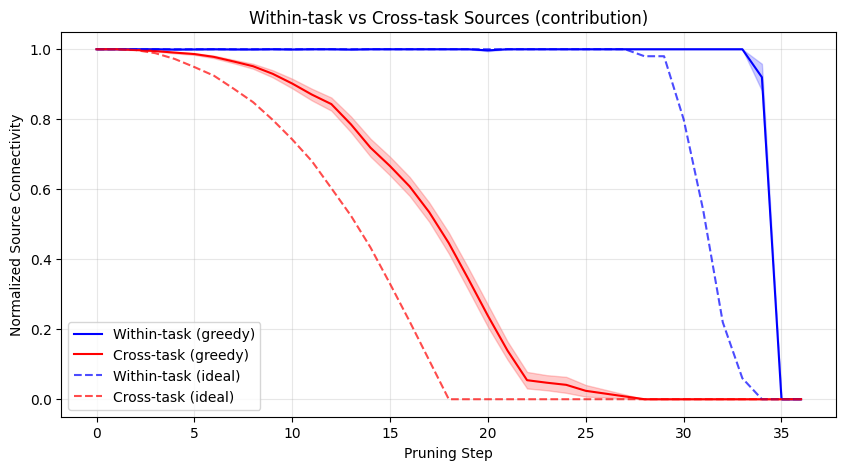

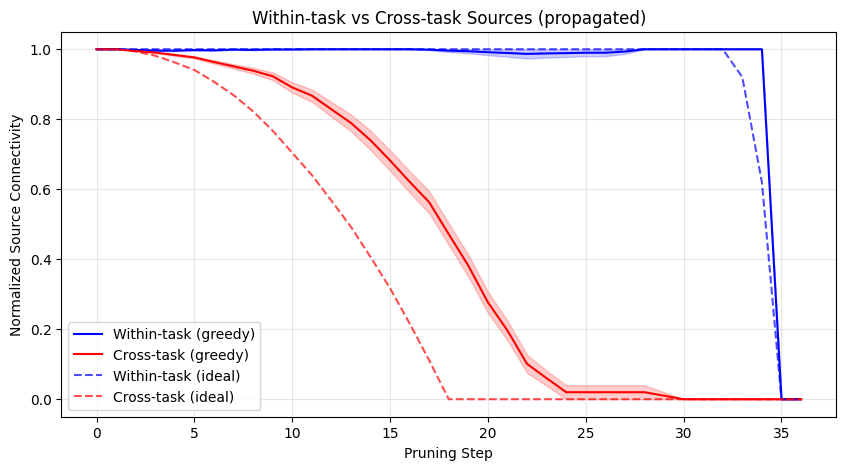

In [10]:
def plot_source_connectivity(all_histories, all_ideal, title_suffix=''):
    n_steps = len(all_histories[0]['within_task'])
    within = np.array([h['within_task'] for h in all_histories])
    cross = np.array([h['cross_task'] for h in all_histories])
    ideal_within = np.array([ib[0] for ib in all_ideal])
    ideal_cross = np.array([ib[1] for ib in all_ideal])
    x = np.arange(n_steps)
    n = len(all_histories)

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(x, within.mean(0), 'b-', label='Within-task (greedy)')
    ax.fill_between(x, within.mean(0) - within.std(0)/np.sqrt(n),
                    within.mean(0) + within.std(0)/np.sqrt(n), alpha=0.2, color='blue')
    ax.plot(x, cross.mean(0), 'r-', label='Cross-task (greedy)')
    ax.fill_between(x, cross.mean(0) - cross.std(0)/np.sqrt(n),
                    cross.mean(0) + cross.std(0)/np.sqrt(n), alpha=0.2, color='red')
    ax.plot(x, ideal_within.mean(0), 'b--', label='Within-task (ideal)', alpha=0.7)
    ax.plot(x, ideal_cross.mean(0), 'r--', label='Cross-task (ideal)', alpha=0.7)
    ax.set_xlabel('Pruning Step'); ax.set_ylabel('Normalized Source Connectivity')
    ax.set_title(f'Within-task vs Cross-task Sources{title_suffix}')
    ax.legend(); ax.grid(True, alpha=0.3)
    plt.show()

for mode in ['contribution', 'propagated']:
    r = all_results[mode]
    plot_source_connectivity(r['histories'], r['ideals'], f' ({mode})')

## Visualization 3: Total utility over pruning

Sum of all active connection utilities at each pruning step. Compares greedy pruning against the ideal baseline. If greedy pruning preserves more utility, it means it's successfully identifying and removing the least important connections.

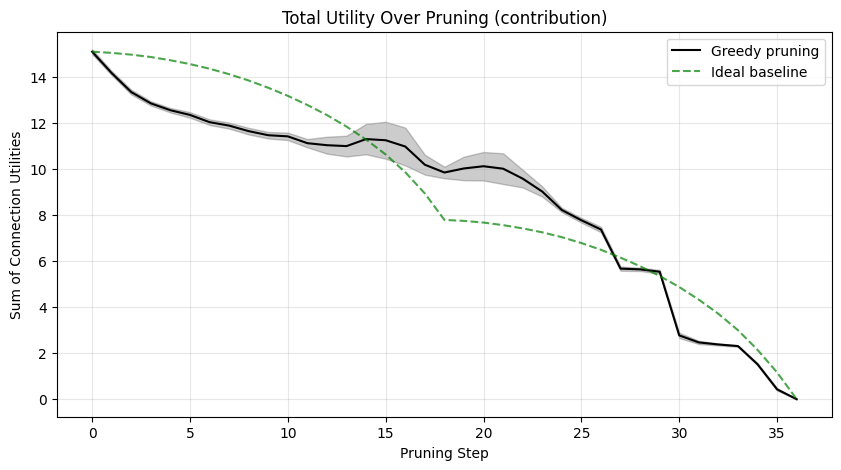

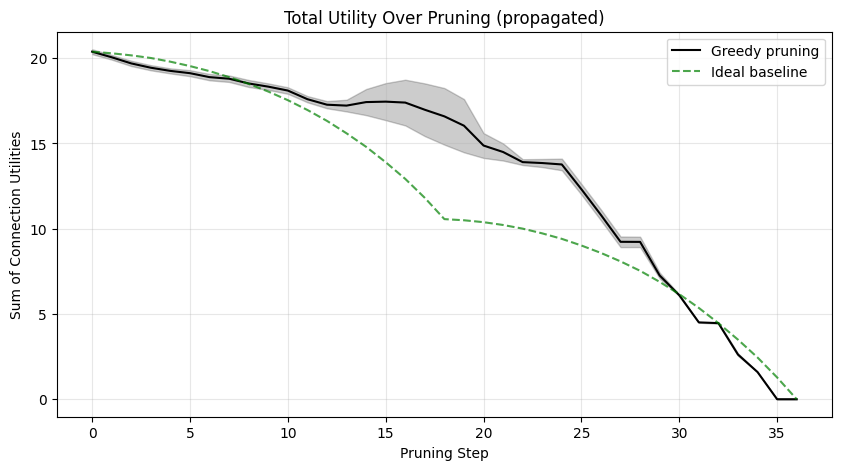

In [11]:
def plot_total_utility(all_histories, all_ideal, title_suffix=''):
    n_steps = len(all_histories[0]['total_utility'])
    greedy = np.array([h['total_utility'] for h in all_histories])
    ideal = np.array([ib[2] for ib in all_ideal])
    x = np.arange(n_steps)
    n = len(all_histories)

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(x, greedy.mean(0), 'k-', label='Greedy pruning')
    ax.fill_between(x, greedy.mean(0) - greedy.std(0)/np.sqrt(n),
                    greedy.mean(0) + greedy.std(0)/np.sqrt(n), alpha=0.2, color='black')
    ax.plot(x, ideal.mean(0), 'g--', label='Ideal baseline', alpha=0.7)
    ax.set_xlabel('Pruning Step'); ax.set_ylabel('Sum of Connection Utilities')
    ax.set_title(f'Total Utility Over Pruning{title_suffix}')
    ax.legend(); ax.grid(True, alpha=0.3)
    plt.show()

for mode in ['contribution', 'propagated']:
    r = all_results[mode]
    plot_total_utility(r['histories'], r['ideals'], f' ({mode})')

## Visualization 4: Utility change by category after each output prune

When an output connection from hidden unit k to output j (task T) is pruned, we measure utilities in 4 categories before and after the network re-stabilizes:

1. **Outgoing same task**: other active output connections from k to task T
2. **Outgoing other task**: active output connections from k to non-T outputs
3. **Incoming same task**: active input connections to k from task T inputs
4. **Incoming other task**: active input connections to k from non-T inputs

The **snowball hypothesis** predicts: outgoing same-task delta is negative (remaining same-task connections lose utility after one is pruned), while outgoing other-task delta is positive (the unit specializes toward the remaining task).

/tmp/ipykernel_11200/3487645399.py:26: RuntimeWarning:

Mean of empty slice

/home/edan/miniconda3/envs/jax/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning:

Degrees of freedom <= 0 for slice.



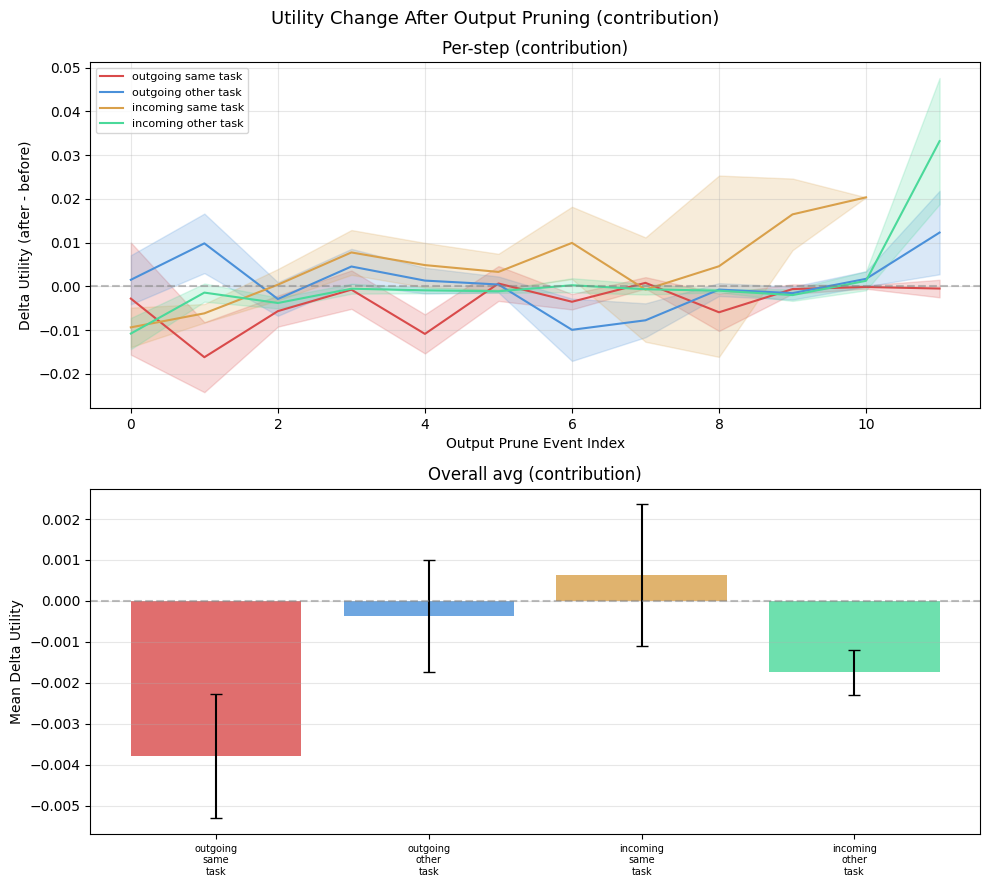

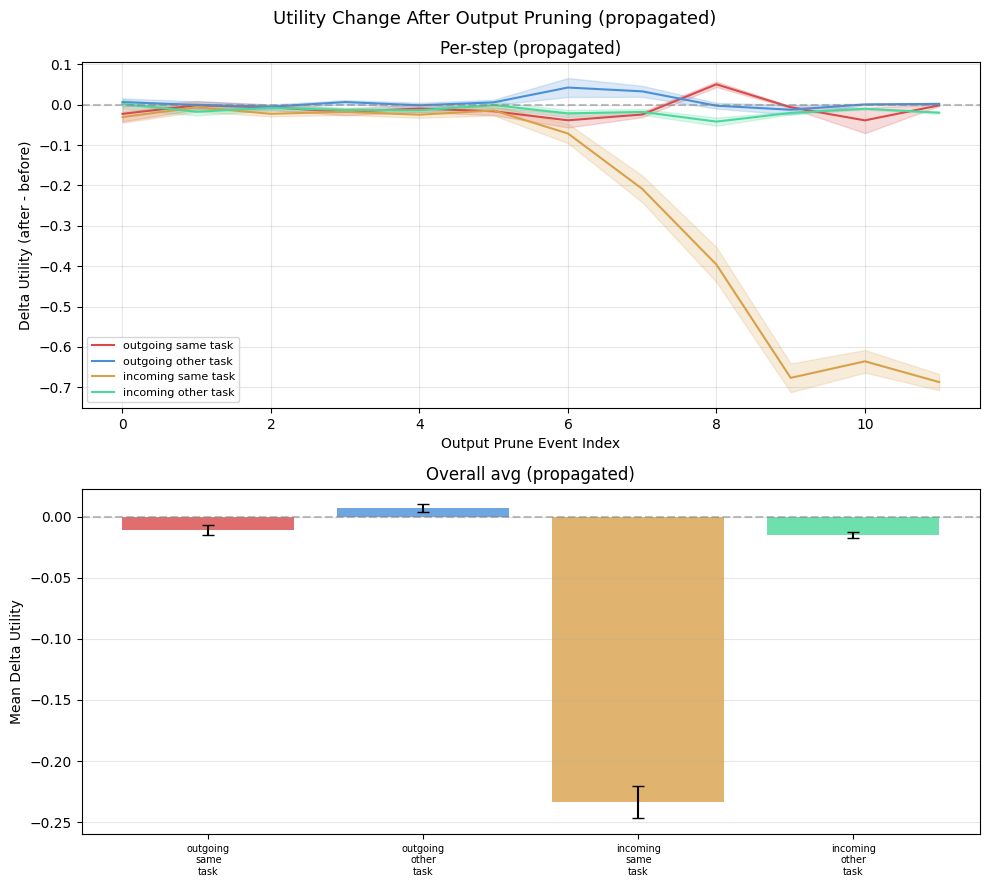

In [12]:
def plot_category_deltas(all_histories, title_suffix=''):
    categories = ['outgoing_same_task', 'outgoing_other_task', 'incoming_same_task', 'incoming_other_task']
    colors = ['#d94a4a', '#4a90d9', '#d9a04a', '#4ad99a']

    max_events = max(sum(1 for d in h['category_deltas'] if d is not None)
                     for h in all_histories)
    per_cat = {c: [] for c in categories}
    for h in all_histories:
        deltas = [d for d in h['category_deltas'] if d is not None]
        for cat in categories:
            vals = [d[cat] for d in deltas if not np.isnan(d[cat])]
            per_cat[cat].append(vals + [np.nan] * (max_events - len(vals)))

    sample = np.array(per_cat[categories[0]])
    n_valid = np.sum(~np.isnan(sample), axis=0)
    n_to_plot = int((n_valid >= len(all_histories) / 2).sum())

    fig, axes = plt.subplots(2, 1, figsize=(10, 9))

    # Left: line plot over prune events
    ax = axes[0]
    if n_to_plot > 0:
        for cat, color in zip(categories, colors):
            data = np.array(per_cat[cat])[:, :n_to_plot]
            nv = np.sum(~np.isnan(data), axis=0)
            mean = np.nanmean(data, axis=0)
            stderr = np.nanstd(data, axis=0) / np.sqrt(np.maximum(nv, 1))
            x = np.arange(len(mean))
            ax.plot(x, mean, color=color, label=cat.replace('_', ' '))
            ax.fill_between(x, mean - stderr, mean + stderr, alpha=0.2, color=color)
        ax.axhline(0, color='gray', linestyle='--', alpha=0.5)
        ax.set_xlabel('Output Prune Event Index')
        ax.set_ylabel('Delta Utility (after - before)')
        ax.set_title(f'Per-step{title_suffix}')
        ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
    else:
        ax.text(0.5, 0.5, 'Not enough data', ha='center', va='center', transform=ax.transAxes)

    # Right: bar plot averaged across ALL events and seeds
    ax2 = axes[1]
    means, stderrs = [], []
    for cat in categories:
        all_vals = []
        for h in all_histories:
            for d in h['category_deltas']:
                if d is not None and not np.isnan(d[cat]):
                    all_vals.append(d[cat])
        means.append(np.mean(all_vals) if all_vals else 0)
        stderrs.append(np.std(all_vals) / np.sqrt(max(len(all_vals), 1)) if all_vals else 0)
    x_bar = np.arange(len(categories))
    ax2.bar(x_bar, means, yerr=stderrs, color=colors, alpha=0.8, capsize=4)
    ax2.set_xticks(x_bar)
    ax2.set_xticklabels([c.replace('_', '\n') for c in categories], fontsize=7)
    ax2.axhline(0, color='gray', linestyle='--', alpha=0.5)
    ax2.set_ylabel('Mean Delta Utility')
    ax2.set_title(f'Overall avg{title_suffix}')
    ax2.grid(True, alpha=0.3, axis='y')

    plt.suptitle(f'Utility Change After Output Pruning{title_suffix}', fontsize=13)
    plt.tight_layout(); plt.show()

for mode in ['contribution', 'propagated']:
    plot_category_deltas(all_results[mode]['histories'], f' ({mode})')


## Visualization 5: Utility change by category after each input prune
Same as Visualization 4, but for **input** connection prune events. When an input connection\n
from input i (task T) to hidden unit k is pruned, we measure the same 4 categories\n
(outgoing same/other task, incoming same/other task) before and after re-stabilization.\n\n
If the snowball effect applies symmetrically, pruning an input from task A should reduce\n
utility of other task-A inputs to that unit and increase utility of task-B inputs.

/tmp/ipykernel_11200/2061528807.py:29: RuntimeWarning:

Mean of empty slice

/home/edan/miniconda3/envs/jax/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning:

Degrees of freedom <= 0 for slice.



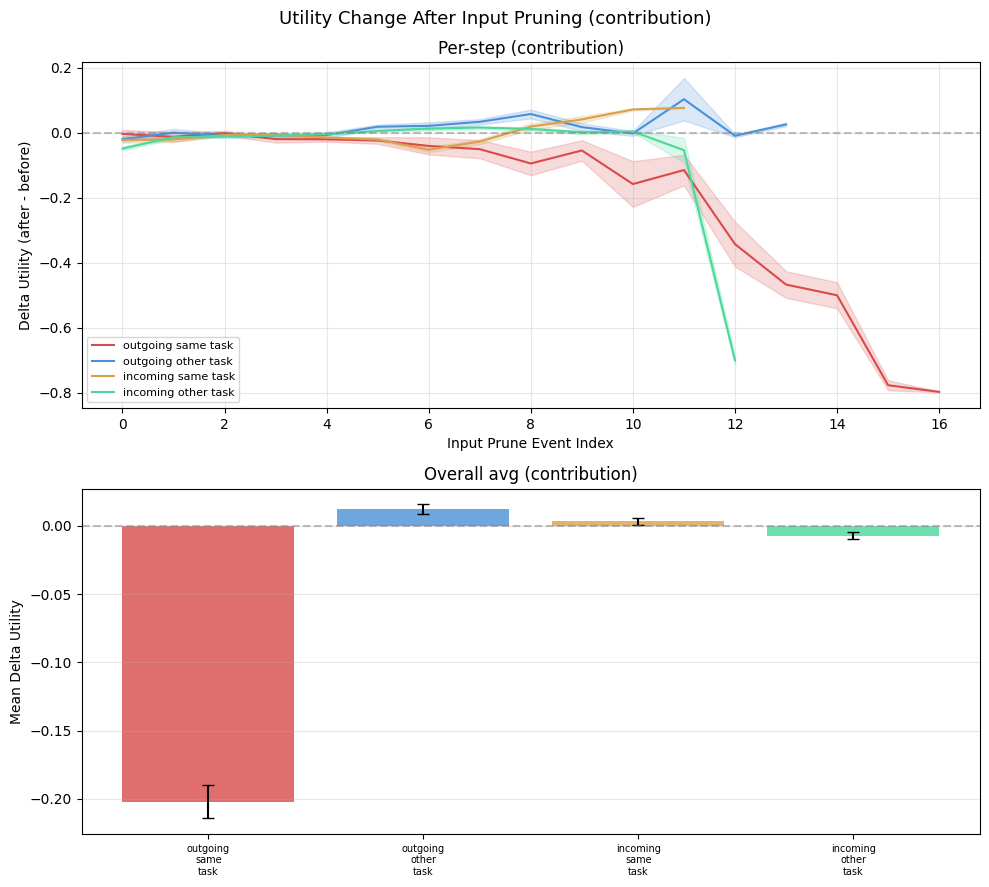

/tmp/ipykernel_11200/2061528807.py:29: RuntimeWarning:

Mean of empty slice

/home/edan/miniconda3/envs/jax/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning:

Degrees of freedom <= 0 for slice.



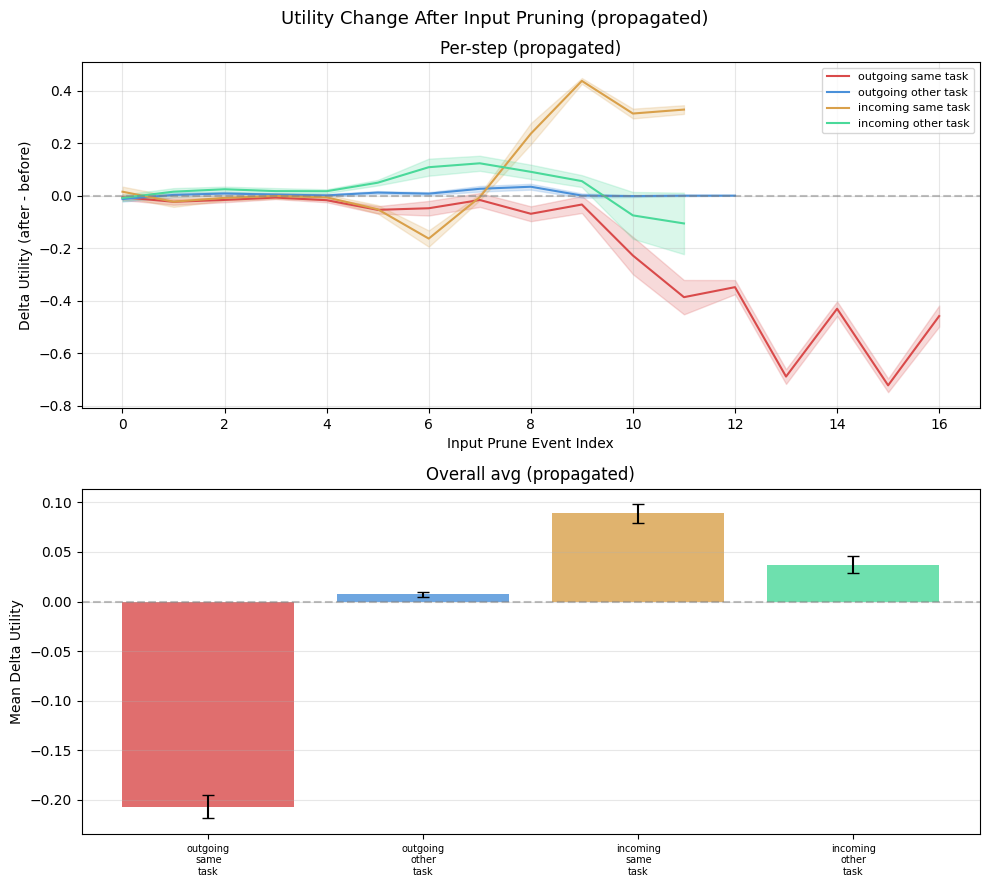

In [13]:
def plot_input_category_deltas(all_histories, title_suffix=''):
    categories = ['outgoing_same_task', 'outgoing_other_task', 'incoming_same_task', 'incoming_other_task']
    colors = ['#d94a4a', '#4a90d9', '#d9a04a', '#4ad99a']

    max_events = max(sum(1 for d in h['input_category_deltas'] if d is not None)
                     for h in all_histories)
    if max_events == 0:
        print('  No input prune events — skipping'); return

    per_cat = {c: [] for c in categories}
    for h in all_histories:
        deltas = [d for d in h['input_category_deltas'] if d is not None]
        for cat in categories:
            vals = [d[cat] for d in deltas if not np.isnan(d[cat])]
            per_cat[cat].append(vals + [np.nan] * (max_events - len(vals)))

    sample = np.array(per_cat[categories[0]])
    n_valid = np.sum(~np.isnan(sample), axis=0)
    n_to_plot = int((n_valid >= len(all_histories) / 2).sum())

    fig, axes = plt.subplots(2, 1, figsize=(10, 9))

    # Left: line plot over prune events
    ax = axes[0]
    if n_to_plot > 0:
        for cat, color in zip(categories, colors):
            data = np.array(per_cat[cat])[:, :n_to_plot]
            nv = np.sum(~np.isnan(data), axis=0)
            mean = np.nanmean(data, axis=0)
            stderr = np.nanstd(data, axis=0) / np.sqrt(np.maximum(nv, 1))
            x = np.arange(len(mean))
            ax.plot(x, mean, color=color, label=cat.replace('_', ' '))
            ax.fill_between(x, mean - stderr, mean + stderr, alpha=0.2, color=color)
        ax.axhline(0, color='gray', linestyle='--', alpha=0.5)
        ax.set_xlabel('Input Prune Event Index')
        ax.set_ylabel('Delta Utility (after - before)')
        ax.set_title(f'Per-step{title_suffix}')
        ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
    else:
        ax.text(0.5, 0.5, 'Not enough data', ha='center', va='center', transform=ax.transAxes)

    # Right: bar plot averaged across ALL events and seeds
    ax2 = axes[1]
    means, stderrs = [], []
    for cat in categories:
        all_vals = []
        for h in all_histories:
            for d in h['input_category_deltas']:
                if d is not None and not np.isnan(d[cat]):
                    all_vals.append(d[cat])
        means.append(np.mean(all_vals) if all_vals else 0)
        stderrs.append(np.std(all_vals) / np.sqrt(max(len(all_vals), 1)) if all_vals else 0)
    x_bar = np.arange(len(categories))
    ax2.bar(x_bar, means, yerr=stderrs, color=colors, alpha=0.8, capsize=4)
    ax2.set_xticks(x_bar)
    ax2.set_xticklabels([c.replace('_', '\n') for c in categories], fontsize=7)
    ax2.axhline(0, color='gray', linestyle='--', alpha=0.5)
    ax2.set_ylabel('Mean Delta Utility')
    ax2.set_title(f'Overall avg{title_suffix}')
    ax2.grid(True, alpha=0.3, axis='y')

    plt.suptitle(f'Utility Change After Input Pruning{title_suffix}', fontsize=13)
    plt.tight_layout(); plt.show()

for mode in ['contribution', 'propagated']:
    plot_input_category_deltas(all_results[mode]['histories'], f' ({mode})')
